In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Settings
upper_end = 6.754
lower_end = -6.754
output_file = "flow.dat"

In [9]:
# Load trajectory (change filenames as needed)
u = mda.Universe('system.psf','MDequil.dcd')
wat = u.select_atoms("name OH2")


In [10]:
def get_status(z_coords):
    status = []
    for z in z_coords:
        if z < lower_end:
            status.append(-1)
        elif z > upper_end:
            status.append(1)
        else:
            status.append(0)
    return np.array(status)

In [11]:
# Initialization
u.trajectory[0]  # First frame
old_status = get_status(wat.positions[:, 2])
total = 0

time=[]
instantflow=[]

with open(output_file, "w") as f:
    for ts in u.trajectory[1:]:
        new_status = get_status(wat.positions[:, 2])
        for old, new in zip(old_status, new_status):
            if old != new and old + new != 0:
                total += new - old
        old_status = new_status.copy()
        time.append(ts.time)
        instantflow.append(total/2.0)
        f.write(f"{ts.frame} {total/2.0}\n")


In [12]:
# Final output
if total > 0:
    print(f"The net flow is {total / 2.0} water molecules along +z")
elif total < 0:
    print(f"The net flow is {-total / 2.0} water molecules along -z")
else:
    print("The net flow is 0")
print("Time evolution saved in a .dat file")


The net flow is 11.0 water molecules along -z
Time evolution saved in a .dat file


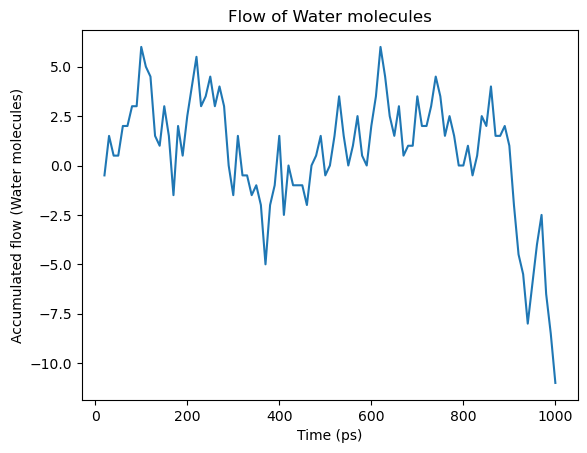

In [13]:
#Plot
plt.plot(time,instantflow)
plt.xlabel('Time (ps)')
plt.ylabel('Accumulated flow (Water molecules)')
plt.title('Flow of Water molecules')
plt.show()
